## Trimming

In [1]:
# trim_memory_chat.py

import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

load_dotenv()

def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7, max_tokens=2000
    )

model = get_groq_llm()

MAX_TOKENS = 120

def chat(state: MessagesState):
    trimmed_messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS,
    )

    response = model.invoke(trimmed_messages)
    return {"messages": [response]}



In [2]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_edge(START, "chat")

graph = builder.compile(checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "trim-demo"}}



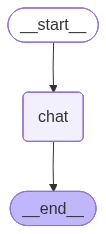

In [3]:
graph

In [4]:
while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit"]:
        break
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config)
    print("Bot:", result["messages"][-1].content)

Bot: Hello! How can I help you today?
Bot: Hi Sachin! I’m here to help—what would you like to know or discuss?
Bot: That’s awesome, Sachin! LangGraph is a powerful way to orchestrate LLM workflows. How can I support you?  
- Are you looking for a quick start guide or a deeper dive into graph design?  
- Need help with a specific use‑case or debugging?  
- Interested in teaching materials or example notebooks?  

Just let me know what you’d like to tackle, and we can dive right in!
Bot: ### LangGraph – The “Graph‑first” LLM Orchestration Framework

| Feature | What it is | Why it matters |
|---------|------------|----------------|
| **Graph‑centric design** | Think of a LangGraph as a directed graph of *nodes* (functions, prompts, tools, LLM calls) and *edges* (control flow). | You can reason about your entire workflow as a single data structure, making it easier to debug, visualize, and evolve. |
| **Stateful, typed state** | A *state* is a typed dictionary that flows through the graph

## Deletion

In [1]:
# delete_memory_chat.py

import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import RemoveMessage

load_dotenv(override=True)

def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7, max_tokens=2000
    )

model = get_groq_llm()

def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def cleanup(state: MessagesState):
    messages = state["messages"]

    if len(messages) > 6:
        to_remove = messages[:4]  # delete oldest messages
        print([m.id for m in to_remove])  # print ids of messages to be removed
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}



In [2]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", cleanup)

builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")
builder.add_edge("cleanup", "__end__")

graph = builder.compile(checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "delete-demo"}}



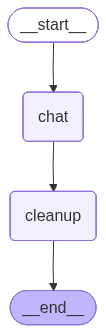

In [3]:
graph

In [4]:
while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit"]:
        break
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config)
    print("Bot:", result["messages"][-1].content)

Bot: Hello! 👋 How can I help you today?
Bot: Nice to meet you, Sachin! How can I help you today?
Bot: It sounds like you’re getting into LangGraph (the framework for building language‑model‑driven applications). That’s awesome! 🚀

What would you like help with?

- Setting up a basic LangGraph workflow?  
- Understanding the core concepts (nodes, edges, state, etc.)?  
- Debugging a specific issue or error you’re seeing?  
- Tips for integrating with your own data sources or APIs?  
- Or something else entirely?

Let me know, and I’ll tailor the guidance to your needs!
['c8fa6c6e-d958-4bd9-929e-5b5a6710cf92', 'lc_run--019e5558-9d68-7bb1-9ebe-4fb7a9fcc36f-0', 'd7ee979b-ff61-4a94-9aab-223ef420e23b', 'lc_run--019e5559-0b3a-7671-812c-b20bb615cbc6-0']
Bot: ### 🚀 What is LangGraph?

LangGraph is an **open‑source framework** that lets you build, compose, and orchestrate complex language‑model (LLM) workflows as *graphs*. Think of it as the “LangChain for graph‑based LLM applications.” It’s des

In [ ]:
# ---- Run ----
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Sachin"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "I am learning LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Explain short term memory"}]}, config)
result = graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)

print(result["messages"][-1].content)


## Summarization

In [1]:
# summary_memory_chat.py

import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, RemoveMessage

load_dotenv(override=True)

def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7, max_tokens=2000
    )

model = get_groq_llm()

class ChatState(MessagesState):
    summary: str

def chat(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])
    response = model.invoke(messages)
    return {"messages": [response]}

def summarize(state: ChatState):
    prompt = "Summarize the conversation so far. in a way that you can include important details in future interactions. like nameof the user, or the person you  are talking & other important deatils."

    summary_input = state["messages"] + [HumanMessage(content=prompt)]
    response = model.invoke(summary_input)

    to_delete = state["messages"][:4] 

    print([m.id for m in to_delete])  # print ids of messages to be removed

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in to_delete],
    }

def should_summarize(state: ChatState):
    return len(state["messages"]) > 6



In [2]:
builder = StateGraph(ChatState)
builder.add_node("chat", chat)
builder.add_node("summarize", summarize)

builder.add_edge(START, "chat")
builder.add_conditional_edges(
    "chat",
    should_summarize,
    {True: "summarize", False: "__end__"}
)
builder.add_edge("summarize", "__end__")

graph = builder.compile(checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "summary-demo"}}


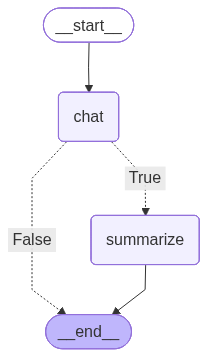

In [3]:
graph


In [4]:
while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit"]:
        break
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}],"summary":""}, config)
    print("Bot:", result["messages"][-1].content)

Bot: Hello! 👋 How can I help you today?
Bot: Nice to meet you, Sachin! How can I assist you today?
Bot: That’s awesome, Sachin! LangGraph is a powerful framework for building graph‑based LLM applications. 🚀

### Quick Recap
- **LangGraph** lets you model your application as a graph of nodes (LLM prompts, logic, APIs, etc.).
- Each node can have **inputs, outputs, and state** that flows through the graph.
- You can orchestrate **prompt chaining, branching, and looping** without writing a ton of boilerplate.

---

## Where to Start

| Step | What to Do | Resources |
|------|------------|-----------|
| 1 | **Set up a basic environment** | • [LangGraph Docs – Quickstart](https://langgraph.org/docs/quickstart) <br>• Install with `pip install langgraph langchain` |
| 2 | **Build your first node** | • Create a simple LLM node that answers a question. <br>• Use the `ChatPromptTemplate` from LangChain. |
| 3 | **Connect nodes** | • Learn how to wire nodes together using `GraphBuilder`. |
| 4 | 

In [29]:


# ---- Run ----
graph.invoke({"messages": [HumanMessage(content="Hi, I'm Sachin")], "summary": ""}, config)
graph.invoke({"messages": [HumanMessage(content="I am learning LangGraph")], "summary": ""}, config)
graph.invoke({"messages": [HumanMessage(content="Explain short term memory")], "summary": ""}, config)
result = graph.invoke({"messages": [HumanMessage(content="What is my name?")], "summary": ""}, config)

print(result["messages"][-1].content)

Your name is Sachin.
